## Monster × VIDEO ELAIS-S1 cross-match — Approach 1

This notebook builds the **Approach 1** VIRCAM reference catalogue for the DP2 ELAIS-S1 tests.

The workflow is designed to be reproducible:

- Monster provides source identifiers and astrometric information only;
- Monster positions are propagated with proper motions only for positional matching;
- native Monster coordinates and astrometric metadata are preserved in the output;
- the effective VIDEO matching epoch is determined empirically;
- a broad epoch scan with 0.5-year spacing is followed by a 0.1-year refinement;
- both median match separation and match counts are inspected as functions of trial epoch;
- the final Gold match requires a mutual nearest neighbour within 0.5 arcsec and Monster second-neighbour separation greater than 1 arcsec;
- VIDEO DR5 Z, Y, J, H, and Ks aperture fluxes and errors are converted from the AB-zeropoint-30 catalogue scale to nJy;
- unmatched Monster rows remain in the output with NaN VIRCAM photometry; and
- one LSST `SimpleCatalog` FITS file is written per HTM7 shard.

No Monster optical photometric field is renamed, copied, or interpreted. This keeps the VIRCAM augmentation independent of Rubin's optical filter mapping and makes the workflow easy to repeat with a later Monster release.

The fitted VIDEO epoch is an **effective astrometric matching epoch**, not a single physical observing epoch for VIDEO.

### Imports

In [1]:
from pathlib import Path

import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy.io import fits
from astropy.table import Table
from astropy.time import Time

import lsst.afw.table as afwTable
from lsst.geom import SpherePoint, radians

### Input and output configuration

The notebook is intended to be run from `dmu2/dmu2_DP2`. The Monster shard list is discovered directly from the filenames.

In [2]:
monster_dir = Path("data/the_monster_20250219/ELAIS1")
vista_file = Path("data/NIR-Catalogs/video-elais-dr5.fits")

outdir = Path("data/video_elais_ap1/the_monster_20250219_vista")
outdir.mkdir(parents=True, exist_ok=True)

monster_files = sorted(monster_dir.glob("refcat_htm7_*.fits"))

if not monster_files:
    raise FileNotFoundError(
        f"No Monster HTM7 shards found in {monster_dir}"
    )

if not vista_file.exists():
    raise FileNotFoundError(vista_file)

htm7_ids = [
    int(path.stem.split("_")[-1])
    for path in monster_files
]

monster_path_by_id = {
    int(path.stem.split("_")[-1]): path
    for path in monster_files
}

print(f"Monster shards: {len(htm7_ids)}")
print(htm7_ids)
print(f"VIDEO catalogue: {vista_file}")
print(f"Output directory: {outdir}")

Monster shards: 24
[145428, 145448, 145449, 145451, 145456, 145620, 145621, 145622, 145623, 145626, 145628, 145630, 145631, 145640, 145642, 145643, 145648, 145649, 145650, 145651, 145657, 145661, 145662, 145663]
VIDEO catalogue: data/NIR-Catalogs/video-elais-dr5.fits
Output directory: data/video_elais_ap1/the_monster_20250219_vista


### Define the VIDEO photometric columns

The VIDEO `APER_2` measurements are used in all five VIRCAM bands. VIDEO catalogue fluxes use an AB zeropoint of 30.0, so both fluxes and flux uncertainties are converted to nJy before writing the reference catalogue.

The VIRCAM output names are `z2`, `y2`, `j`, `h`, and `ks`. The `z2` and `y2` names keep VIRCAM Z/Y distinct from optical reference-band names.

In [3]:
VIDEO_ZP_AB = 30.0

VIDEO_ADU_TO_NJY = (
    VIDEO_ZP_AB * u.ABmag
).to_value(u.nJy)

vista_cols = [
    "KS_FLUX_APER_2", "KS_FLUXERR_APER_2",
    "J_FLUX_APER_2",  "J_FLUXERR_APER_2",
    "H_FLUX_APER_2",  "H_FLUXERR_APER_2",
    "Y_FLUX_APER_2",  "Y_FLUXERR_APER_2",
    "Z_FLUX_APER_2",  "Z_FLUXERR_APER_2",
]

vista_rename = {
    "KS_FLUX_APER_2": "ks_flux",
    "KS_FLUXERR_APER_2": "ks_fluxErr",
    "J_FLUX_APER_2": "j_flux",
    "J_FLUXERR_APER_2": "j_fluxErr",
    "H_FLUX_APER_2": "h_flux",
    "H_FLUXERR_APER_2": "h_fluxErr",
    "Y_FLUX_APER_2": "y2_flux",
    "Y_FLUXERR_APER_2": "y2_fluxErr",
    "Z_FLUX_APER_2": "z2_flux",
    "Z_FLUXERR_APER_2": "z2_fluxErr",
}

print(
    f"1 VIDEO catalogue flux unit = "
    f"{VIDEO_ADU_TO_NJY:.6f} nJy"
)

1 VIDEO catalogue flux unit = 3.630781 nJy


### Load only the required VIDEO columns

The VIDEO band-merged catalogue is wide. To avoid loading hundreds of unused columns, the FITS file is memory-mapped and only the two coordinate columns plus the ten required aperture-flux/error columns are copied into memory.

In [4]:
required_vista_cols = [
    "RA2000",
    "DEC2000",
] + vista_cols

with fits.open(vista_file, memmap=True) as hdul:

    table_hdu = next(
        (
            hdu
            for hdu in hdul
            if isinstance(hdu, fits.BinTableHDU)
            and hdu.data is not None
        ),
        None,
    )

    if table_hdu is None:
        raise RuntimeError(
            f"No binary-table HDU found in {vista_file}"
        )

    available_cols = set(table_hdu.columns.names)

    missing_vista_cols = [
        name
        for name in required_vista_cols
        if name not in available_cols
    ]

    if missing_vista_cols:
        raise KeyError(
            "Missing VIDEO columns: "
            + ", ".join(missing_vista_cols)
        )

    vista = Table(
        {
            name: np.array(
                table_hdu.data[name],
                copy=True,
            )
            for name in required_vista_cols
        }
    )

finite_coord = (
    np.isfinite(np.asarray(vista["RA2000"], dtype=float))
    & np.isfinite(np.asarray(vista["DEC2000"], dtype=float))
)

vista = vista[finite_coord]

vis_coords = SkyCoord(
    ra=np.asarray(vista["RA2000"], dtype=float) * u.deg,
    dec=np.asarray(vista["DEC2000"], dtype=float) * u.deg,
)

print(f"VIDEO ELAIS-S1 rows retained: {len(vista):,}")
print(f"VIDEO columns retained: {len(vista.colnames)}")

VIDEO ELAIS-S1 rows retained: 842,337
VIDEO columns retained: 12


### Matching helper functions

Monster coordinates are stored in radians and proper motions in rad yr$^{-1}$. For a trial epoch, only rows with finite coordinates, proper motions, and epochs are propagated.

The propagation function returns the original Monster row indices so that matched VIDEO measurements can be attached directly to the correct native Monster rows.

The mutual-nearest-neighbour criterion is exact. The reverse match is evaluated only for VIDEO objects that are candidate nearest neighbours within the search radius, avoiding a much larger unnecessary reverse query.

In [5]:
VISTA_MARGIN_DEG = 0.6


def local_vista_cut(ra_deg, dec_deg, margin_deg=VISTA_MARGIN_DEG):
    """Select VIDEO sources near one Monster HTM7 shard."""

    ra_min = np.nanmin(ra_deg) - margin_deg
    ra_max = np.nanmax(ra_deg) + margin_deg
    dec_min = np.nanmin(dec_deg) - margin_deg
    dec_max = np.nanmax(dec_deg) + margin_deg

    return (
        (np.asarray(vista["RA2000"], dtype=float) > ra_min)
        & (np.asarray(vista["RA2000"], dtype=float) < ra_max)
        & (np.asarray(vista["DEC2000"], dtype=float) > dec_min)
        & (np.asarray(vista["DEC2000"], dtype=float) < dec_max)
    )


def monster_to_mjd_pm_only(mon_tbl, mjd_target):
    """Propagate Monster positions with proper motions only."""

    ra0 = np.asarray(mon_tbl["coord_ra"], dtype=float)
    dec0 = np.asarray(mon_tbl["coord_dec"], dtype=float)
    pmra = np.asarray(mon_tbl["pm_ra"], dtype=float)
    pmdec = np.asarray(mon_tbl["pm_dec"], dtype=float)
    epoch = np.asarray(mon_tbl["epoch"], dtype=float)

    valid = (
        np.isfinite(ra0)
        & np.isfinite(dec0)
        & np.isfinite(pmra)
        & np.isfinite(pmdec)
        & np.isfinite(epoch)
        & (np.abs(np.cos(dec0)) > 1.0e-12)
    )

    original_index = np.flatnonzero(valid)

    ra0 = ra0[valid]
    dec0 = dec0[valid]
    pmra = pmra[valid]
    pmdec = pmdec[valid]
    epoch = epoch[valid]

    dt_year = (mjd_target - epoch) / 365.25

    # pm_ra is mu_alpha* = d(alpha)/dt cos(delta).
    ra1 = ra0 + (pmra * dt_year) / np.cos(dec0)
    dec1 = dec0 + pmdec * dt_year

    finite = np.isfinite(ra1) & np.isfinite(dec1)

    coords = SkyCoord(
        ra=ra1[finite] * u.rad,
        dec=dec1[finite] * u.rad,
    )

    return coords, original_index[finite]


def mutual_nn_match(coords_a, coords_b, radius):
    """Return mutual nearest-neighbour matches from A to B."""

    if len(coords_a) == 0 or len(coords_b) == 0:
        return (
            np.zeros(len(coords_a), dtype=bool),
            np.zeros(len(coords_a), dtype=int),
            np.full(len(coords_a), np.inf) * u.arcsec,
        )

    idx_b, sep_ab, _ = match_coordinates_sky(
        coords_a,
        coords_b,
    )

    within = sep_ab < radius

    candidate_b = np.unique(
        idx_b[within]
    )

    reverse_nearest = {}

    if len(candidate_b) > 0:
        idx_a_back, _, _ = match_coordinates_sky(
            coords_b[candidate_b],
            coords_a,
        )

        reverse_nearest = {
            int(b_index): int(a_index)
            for b_index, a_index
            in zip(candidate_b, idx_a_back)
        }

    mutual = np.fromiter(
        (
            reverse_nearest.get(int(b_index), -1)
            == a_index
            for a_index, b_index
            in enumerate(idx_b)
        ),
        dtype=bool,
        count=len(idx_b),
    )

    good = within & mutual

    return good, idx_b, sep_ab


def isolate_mask(coords, min_sep):
    """Require the second-nearest Monster neighbour to be farther away."""

    if len(coords) < 2:
        return np.ones(len(coords), dtype=bool)

    _, sep2, _ = match_coordinates_sky(
        coords,
        coords,
        nthneighbor=2,
    )

    return sep2 > min_sep

### Load the Monster astrometric backbone

Only the Monster fields required for the VIRCAM reference catalogue are retained. These tables are reused for the epoch scans and the final build so the Monster files are not repeatedly read during every trial epoch.

In [6]:
ASTROMETRY_FIELDS = [
    "id",
    "coord_ra",
    "coord_dec",
    "coord_raErr",
    "coord_decErr",
    "epoch",
    "pm_ra",
    "pm_dec",
    "pm_raErr",
    "pm_decErr",
    "parallax",
    "parallaxErr",
]

monster_tables = {}
local_video_indices = {}

for shard_id in htm7_ids:

    mon_full = Table.read(
        monster_path_by_id[shard_id]
    )

    missing_astrometry = [
        name
        for name in ASTROMETRY_FIELDS
        if name not in mon_full.colnames
    ]

    if missing_astrometry:
        raise KeyError(
            f"HTM7 {shard_id} is missing required Monster fields: "
            + ", ".join(missing_astrometry)
        )

    mon = mon_full[
        ASTROMETRY_FIELDS
    ].copy(copy_data=True)

    monster_tables[shard_id] = mon

    ra_native_deg = np.degrees(
        np.asarray(mon["coord_ra"], dtype=float)
    )
    dec_native_deg = np.degrees(
        np.asarray(mon["coord_dec"], dtype=float)
    )

    local_video_indices[shard_id] = np.flatnonzero(
        local_vista_cut(
            ra_native_deg,
            dec_native_deg,
        )
    )

    print(
        f"HTM7 {shard_id}: "
        f"Monster rows={len(mon):5d}  "
        f"local VIDEO rows="
        f"{len(local_video_indices[shard_id]):7d}"
    )

HTM7 145428: Monster rows= 1562  local VIDEO rows= 181109
HTM7 145448: Monster rows= 1477  local VIDEO rows= 310075
HTM7 145449: Monster rows= 1535  local VIDEO rows= 157077
HTM7 145451: Monster rows= 1375  local VIDEO rows= 225998
HTM7 145456: Monster rows= 1437  local VIDEO rows= 217403
HTM7 145620: Monster rows= 1496  local VIDEO rows= 691693
HTM7 145621: Monster rows= 1486  local VIDEO rows= 529159
HTM7 145622: Monster rows= 1546  local VIDEO rows= 402859
HTM7 145623: Monster rows= 1406  local VIDEO rows= 592796
HTM7 145626: Monster rows= 1433  local VIDEO rows= 130431
HTM7 145628: Monster rows= 1377  local VIDEO rows= 340025
HTM7 145630: Monster rows= 1419  local VIDEO rows= 209774
HTM7 145631: Monster rows= 1392  local VIDEO rows= 225586
HTM7 145640: Monster rows= 1576  local VIDEO rows= 364903
HTM7 145642: Monster rows= 1544  local VIDEO rows= 128381
HTM7 145643: Monster rows= 1528  local VIDEO rows= 209136
HTM7 145648: Monster rows= 1498  local VIDEO rows= 593813
HTM7 145649: M

### Inspect the native Monster epoch

This documents the astrometric epoch of the Monster reference catalogue before any proper-motion propagation.

In [7]:
monster_epochs = np.concatenate(
    [
        np.asarray(mon["epoch"], dtype=float)
        for mon in monster_tables.values()
    ]
)

monster_epochs = monster_epochs[
    np.isfinite(monster_epochs)
]

median_monster_mjd = np.median(
    monster_epochs
)

print(f"Median Monster MJD: {median_monster_mjd:.2f}")
print(f"Minimum Monster MJD: {np.min(monster_epochs):.2f}")
print(f"Maximum Monster MJD: {np.max(monster_epochs):.2f}")
print(
    "Median Monster Julian year: "
    f"{Time(median_monster_mjd, format='mjd').jyear:.6f}"
)

Median Monster MJD: 57388.50
Minimum Monster MJD: 57388.50
Maximum Monster MJD: 57388.50
Median Monster Julian year: 2015.999998


### Epoch-scan helper

The effective VIDEO matching epoch is determined by minimizing the **median Monster–VIDEO separation**.

For the scan only, a loose 1.0-arcsec match radius is used so the diagnostic remains stable while the propagated positions move. The same 1.0-arcsec Monster isolation criterion is used throughout.

For every trial epoch the notebook records the number of mutual matches, the median separation, and the NMAD of the separation distribution.

In [8]:
SCAN_RADIUS = 1.0 * u.arcsec
SCAN_ISO_MIN_SEP = 1.0 * u.arcsec


def run_epoch_scan(epoch_grid):
    """Evaluate Monster-VIDEO match quality over trial epochs."""

    rows = []

    for trial_epoch in epoch_grid:

        mjd_trial = Time(
            trial_epoch,
            format="jyear",
        ).mjd

        separations_all = []
        n_matches = 0

        for shard_id in htm7_ids:

            mon = monster_tables[shard_id]
            local_idx = local_video_indices[shard_id]

            if len(local_idx) == 0:
                continue

            coords_vista = vis_coords[local_idx]

            coords_monster, mon_use_index = (
                monster_to_mjd_pm_only(
                    mon,
                    mjd_trial,
                )
            )

            if len(coords_monster) == 0:
                continue

            isolation = isolate_mask(
                coords_monster,
                SCAN_ISO_MIN_SEP,
            )

            coords_monster_iso = coords_monster[
                isolation
            ]

            if len(coords_monster_iso) == 0:
                continue

            matched, idx_vista, sep = mutual_nn_match(
                coords_monster_iso,
                coords_vista,
                SCAN_RADIUS,
            )

            sep_arcsec = sep[matched].to_value(
                u.arcsec
            )

            if len(sep_arcsec) > 0:
                separations_all.append(
                    sep_arcsec
                )
                n_matches += len(
                    sep_arcsec
                )

        if separations_all:
            separations_all = np.concatenate(
                separations_all
            )

            median_sep = np.nanmedian(
                separations_all
            )

            nmad_sep = (
                1.4826
                * np.nanmedian(
                    np.abs(
                        separations_all
                        - median_sep
                    )
                )
            )
        else:
            median_sep = np.nan
            nmad_sep = np.nan

        rows.append(
            (
                float(trial_epoch),
                int(n_matches),
                float(median_sep),
                float(nmad_sep),
            )
        )

        print(
            f"epoch={trial_epoch:6.2f}  "
            f"matches={n_matches:7d}  "
            f"median_sep={median_sep:7.4f}\"  "
            f"NMAD={nmad_sep:7.4f}\""
        )

    return Table(
        rows=rows,
        names=[
            "epoch",
            "nmatch",
            "median_sep",
            "nmad_sep",
        ],
    )


def best_epoch_from_scan(scan_table):
    """Return the epoch with the smallest finite median separation."""

    median_sep = np.asarray(
        scan_table["median_sep"],
        dtype=float,
    )

    good = np.isfinite(
        median_sep
    )

    if not np.any(good):
        raise RuntimeError(
            "No valid matches were found in the epoch scan."
        )

    good_indices = np.flatnonzero(
        good
    )

    best_index = good_indices[
        np.argmin(
            median_sep[good]
        )
    ]

    return float(
        scan_table["epoch"][
            best_index
        ]
    )

### Coarse epoch scan — 0.5-year spacing

The first pass covers Julian years 2000.0–2018.5 with 0.5-year spacing. This locates the broad minimum without assuming an effective VIDEO epoch in advance.

In [9]:
coarse_epoch_grid = np.arange(
    2000.0,
    2019.0,
    0.5,
)

coarse_scan = run_epoch_scan(
    coarse_epoch_grid
)

COARSE_BEST_EPOCH = (
    best_epoch_from_scan(
        coarse_scan
    )
)

print(
    "\nBest coarse effective epoch: "
    f"{COARSE_BEST_EPOCH:.2f}"
)

epoch=2000.00  matches=   9353  median_sep= 0.1468"  NMAD= 0.0926"
epoch=2000.50  matches=   9357  median_sep= 0.1445"  NMAD= 0.0902"
epoch=2001.00  matches=   9362  median_sep= 0.1427"  NMAD= 0.0883"
epoch=2001.50  matches=   9370  median_sep= 0.1412"  NMAD= 0.0864"
epoch=2002.00  matches=   9373  median_sep= 0.1391"  NMAD= 0.0843"
epoch=2002.50  matches=   9376  median_sep= 0.1378"  NMAD= 0.0825"
epoch=2003.00  matches=   9378  median_sep= 0.1359"  NMAD= 0.0802"
epoch=2003.50  matches=   9383  median_sep= 0.1342"  NMAD= 0.0782"
epoch=2004.00  matches=   9386  median_sep= 0.1329"  NMAD= 0.0755"
epoch=2004.50  matches=   9389  median_sep= 0.1318"  NMAD= 0.0738"
epoch=2005.00  matches=   9390  median_sep= 0.1305"  NMAD= 0.0723"
epoch=2005.50  matches=   9392  median_sep= 0.1292"  NMAD= 0.0708"
epoch=2006.00  matches=   9396  median_sep= 0.1284"  NMAD= 0.0696"
epoch=2006.50  matches=   9400  median_sep= 0.1279"  NMAD= 0.0685"
epoch=2007.00  matches=   9399  median_sep= 0.1278"  NMAD= 0.0

### Coarse-scan median separation

The broad minimum determines the centre of the fine scan.

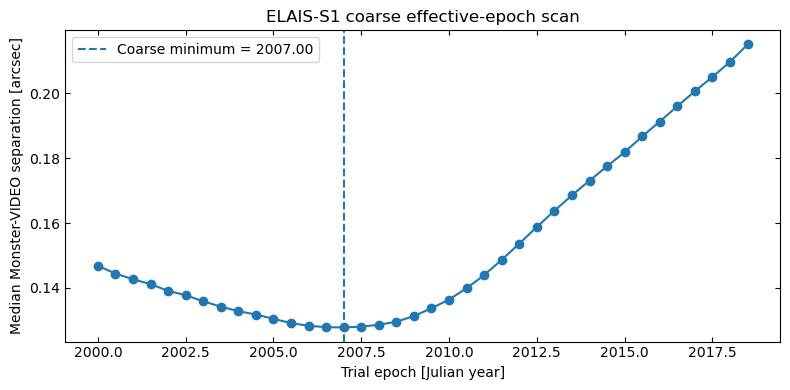

In [10]:
fig, ax = plt.subplots(
    figsize=(8, 4)
)

ax.plot(
    coarse_scan["epoch"],
    coarse_scan["median_sep"],
    marker="o",
)

ax.axvline(
    COARSE_BEST_EPOCH,
    linestyle="--",
    label=(
        "Coarse minimum = "
        f"{COARSE_BEST_EPOCH:.2f}"
    ),
)

ax.set_xlabel("Trial epoch [Julian year]")
ax.set_ylabel(
    "Median Monster-VIDEO separation [arcsec]"
)
ax.set_title(
    "ELAIS-S1 coarse effective-epoch scan"
)
ax.tick_params(
    direction="in",
    top=True,
    right=True,
)
ax.legend()

plt.tight_layout()
plt.show()

### Coarse-scan match counts

The match count is inspected alongside the separation minimum to verify that the preferred epoch is not produced by a sharp loss of matched sources.

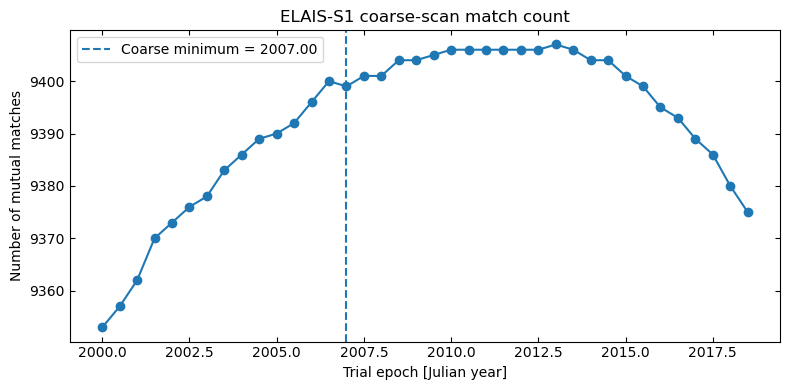

In [11]:
fig, ax = plt.subplots(
    figsize=(8, 4)
)

ax.plot(
    coarse_scan["epoch"],
    coarse_scan["nmatch"],
    marker="o",
)

ax.axvline(
    COARSE_BEST_EPOCH,
    linestyle="--",
    label=(
        "Coarse minimum = "
        f"{COARSE_BEST_EPOCH:.2f}"
    ),
)

ax.set_xlabel("Trial epoch [Julian year]")
ax.set_ylabel("Number of mutual matches")
ax.set_title(
    "ELAIS-S1 coarse-scan match count"
)
ax.tick_params(
    direction="in",
    top=True,
    right=True,
)
ax.legend()

plt.tight_layout()
plt.show()

### Fine epoch scan — 0.1-year spacing

The coarse minimum is refined over a ±1-year interval with 0.1-year spacing.

The final effective epoch is selected from this fine scan by minimizing the median separation. It is therefore reproduced from the data rather than hard-coded.

In [12]:
fine_epoch_grid = np.round(
    np.arange(
        COARSE_BEST_EPOCH - 1.0,
        COARSE_BEST_EPOCH + 1.0 + 0.05,
        0.1,
    ),
    10,
)

fine_scan = run_epoch_scan(
    fine_epoch_grid
)

VIDEO_EPOCH_JYEAR = (
    best_epoch_from_scan(
        fine_scan
    )
)

MJD_VIDEO = Time(
    VIDEO_EPOCH_JYEAR,
    format="jyear",
).mjd

print(
    "\nFinal effective VIDEO matching epoch:"
)
print(
    f"VIDEO_EPOCH_JYEAR = "
    f"{VIDEO_EPOCH_JYEAR:.2f}"
)
print(
    f"MJD_VIDEO         = "
    f"{MJD_VIDEO:.2f}"
)

epoch=2006.00  matches=   9396  median_sep= 0.1284"  NMAD= 0.0696"
epoch=2006.10  matches=   9396  median_sep= 0.1282"  NMAD= 0.0694"
epoch=2006.20  matches=   9398  median_sep= 0.1282"  NMAD= 0.0688"
epoch=2006.30  matches=   9399  median_sep= 0.1279"  NMAD= 0.0688"
epoch=2006.40  matches=   9399  median_sep= 0.1280"  NMAD= 0.0687"
epoch=2006.50  matches=   9400  median_sep= 0.1279"  NMAD= 0.0685"
epoch=2006.60  matches=   9399  median_sep= 0.1277"  NMAD= 0.0686"
epoch=2006.70  matches=   9399  median_sep= 0.1276"  NMAD= 0.0682"
epoch=2006.80  matches=   9399  median_sep= 0.1278"  NMAD= 0.0682"
epoch=2006.90  matches=   9399  median_sep= 0.1279"  NMAD= 0.0682"
epoch=2007.00  matches=   9399  median_sep= 0.1278"  NMAD= 0.0679"
epoch=2007.10  matches=   9399  median_sep= 0.1279"  NMAD= 0.0677"
epoch=2007.20  matches=   9399  median_sep= 0.1280"  NMAD= 0.0677"
epoch=2007.30  matches=   9400  median_sep= 0.1279"  NMAD= 0.0675"
epoch=2007.40  matches=   9400  median_sep= 0.1279"  NMAD= 0.0

### Fine-scan median separation

This figure documents the 0.1-year refinement used to select the final effective VIDEO matching epoch.

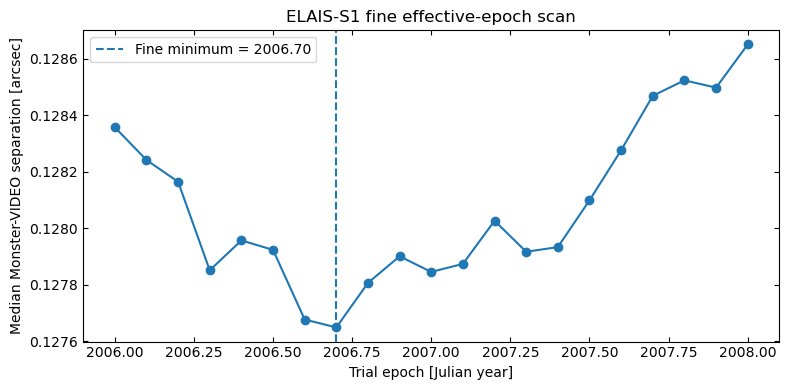

In [13]:
fig, ax = plt.subplots(
    figsize=(8, 4)
)

ax.plot(
    fine_scan["epoch"],
    fine_scan["median_sep"],
    marker="o",
)

ax.axvline(
    VIDEO_EPOCH_JYEAR,
    linestyle="--",
    label=(
        "Fine minimum = "
        f"{VIDEO_EPOCH_JYEAR:.2f}"
    ),
)

ax.set_xlabel("Trial epoch [Julian year]")
ax.set_ylabel(
    "Median Monster-VIDEO separation [arcsec]"
)
ax.set_title(
    "ELAIS-S1 fine effective-epoch scan"
)
ax.tick_params(
    direction="in",
    top=True,
    right=True,
)
ax.legend()

plt.tight_layout()
plt.show()

### Fine-scan match counts

The fine-scan counts provide a second check that the selected epoch corresponds to improved positional agreement rather than a change in sample size.

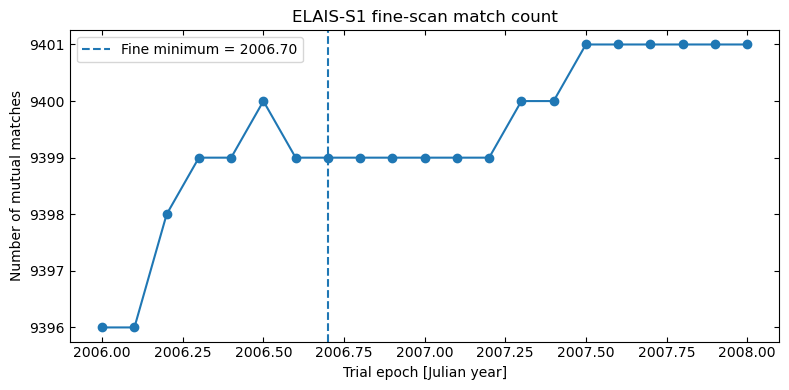

In [14]:
fig, ax = plt.subplots(
    figsize=(8, 4)
)

ax.plot(
    fine_scan["epoch"],
    fine_scan["nmatch"],
    marker="o",
)

ax.axvline(
    VIDEO_EPOCH_JYEAR,
    linestyle="--",
    label=(
        "Fine minimum = "
        f"{VIDEO_EPOCH_JYEAR:.2f}"
    ),
)

ax.set_xlabel("Trial epoch [Julian year]")
ax.set_ylabel("Number of mutual matches")
ax.set_title(
    "ELAIS-S1 fine-scan match count"
)
ax.tick_params(
    direction="in",
    top=True,
    right=True,
)
ax.legend()

plt.tight_layout()
plt.show()

### Final Gold matching configuration

The epoch scans use a loose 1.0-arcsec search radius for diagnostics. The production cross-match is stricter:

- mutual nearest neighbour within 0.5 arcsec;
- Monster second-nearest-neighbour separation greater than 1 arcsec.

The effective epoch obtained above is used only for matching; output coordinates remain the native Monster coordinates.

In [15]:
MATCH_RADIUS = 0.5 * u.arcsec
ISO_MIN_SEP = 1.0 * u.arcsec

print(
    f"VIDEO_EPOCH_JYEAR = {VIDEO_EPOCH_JYEAR:.2f}"
)
print(
    f"MJD_VIDEO         = {MJD_VIDEO:.2f}"
)
print(
    f"MATCH_RADIUS      = {MATCH_RADIUS}"
)
print(
    f"ISO_MIN_SEP       = {ISO_MIN_SEP}"
)

VIDEO_EPOCH_JYEAR = 2006.70
MJD_VIDEO         = 53991.68
MATCH_RADIUS      = 0.5 arcsec
ISO_MIN_SEP       = 1.0 arcsec


### Define the minimal VIRCAM reference-catalogue schema

A new LSST `SimpleCatalog` is created from scratch.

The schema contains only the standard minimal source ID and sky coordinates, Monster astrometric metadata, VIRCAM `z2`, `y2`, `j`, `h`, and `ks` fluxes/errors in nJy, and the Monster–VIDEO match separation.

No ComCam, DES, LATISS, SDSS, or other Monster photometric fields are included in Approach 1.

In [16]:
schema = (
    afwTable.SimpleTable.makeMinimalSchema()
)

for band in [
    "z2",
    "y2",
    "j",
    "h",
    "ks",
]:
    schema.addField(
        f"{band}_flux",
        type="D",
        doc=f"VIRCAM {band} reference flux",
        units="nJy",
    )
    schema.addField(
        f"{band}_fluxErr",
        type="D",
        doc=f"Uncertainty on VIRCAM {band} reference flux",
        units="nJy",
    )

schema.addField(
    "coord_raErr",
    type="D",
    doc="Uncertainty on right ascension",
    units="rad",
)
schema.addField(
    "coord_decErr",
    type="D",
    doc="Uncertainty on declination",
    units="rad",
)
schema.addField(
    "epoch",
    type="D",
    doc="Astrometric reference epoch in MJD",
    units="d",
)
schema.addField(
    "pm_ra",
    type="D",
    doc="Proper motion in right ascension including cos(dec)",
    units="rad/yr",
)
schema.addField(
    "pm_dec",
    type="D",
    doc="Proper motion in declination",
    units="rad/yr",
)
schema.addField(
    "pm_raErr",
    type="D",
    doc="Uncertainty on pm_ra",
    units="rad/yr",
)
schema.addField(
    "pm_decErr",
    type="D",
    doc="Uncertainty on pm_dec",
    units="rad/yr",
)
schema.addField(
    "parallax",
    type="D",
    doc="Parallax",
    units="rad",
)
schema.addField(
    "parallaxErr",
    type="D",
    doc="Uncertainty on parallax",
    units="rad",
)
schema.addField(
    "vista_sep_arcsec",
    type="D",
    doc="Monster to VIDEO Gold-match separation",
    units="arcsec",
)


scalar_fields = [
    "coord_raErr",
    "coord_decErr",
    "epoch",
    "pm_ra",
    "pm_dec",
    "pm_raErr",
    "pm_decErr",
    "parallax",
    "parallaxErr",
    "z2_flux",
    "z2_fluxErr",
    "y2_flux",
    "y2_fluxErr",
    "j_flux",
    "j_fluxErr",
    "h_flux",
    "h_fluxErr",
    "ks_flux",
    "ks_fluxErr",
    "vista_sep_arcsec",
]

scalar_keys = {
    name: schema.find(name).key
    for name in scalar_fields
}

print(
    "Output schema field count:",
    len(schema.getNames()),
)

Output schema field count: 23


### Build the Approach 1 HTM7 shards

For each shard the native Monster astrometric table is matched to the local VIDEO catalogue at the fitted effective epoch. VIDEO ZYJHKs fluxes and errors are converted to nJy and attached to the matching native Monster rows.

The output is built as a **new contiguous `SimpleCatalog` from the minimal schema**. The original Monster AFW catalogue is never copied or extended, avoiding the non-contiguous-record problem encountered with the full Monster schema.

In [17]:
all_separations = {}
build_summary = []

for shard_id in htm7_ids:

    mon = monster_tables[shard_id]
    n_monster = len(mon)

    local_idx = local_video_indices[
        shard_id
    ]

    coords_vista = vis_coords[
        local_idx
    ]

    coords_monster, mon_use_index = (
        monster_to_mjd_pm_only(
            mon,
            MJD_VIDEO,
        )
    )

    isolation = isolate_mask(
        coords_monster,
        ISO_MIN_SEP,
    )

    coords_monster_iso = coords_monster[
        isolation
    ]

    mon_iso_index = mon_use_index[
        isolation
    ]

    sep_video = np.full(
        n_monster,
        np.nan,
        dtype=float,
    )

    vista_values = {
        output_name: np.full(
            n_monster,
            np.nan,
            dtype=float,
        )
        for output_name
        in vista_rename.values()
    }

    if (
        len(coords_monster_iso) > 0
        and len(coords_vista) > 0
    ):

        matched, idx_vista, sep = (
            mutual_nn_match(
                coords_monster_iso,
                coords_vista,
                MATCH_RADIUS,
            )
        )

        sep_good = sep[
            matched
        ].to_value(
            u.arcsec
        )

        all_separations[
            shard_id
        ] = sep_good

        if np.any(matched):

            ii = mon_iso_index[
                matched
            ]

            jj_local = idx_vista[
                matched
            ]

            jj_global = local_idx[
                jj_local
            ]

            sep_video[ii] = sep_good

            for (
                input_name,
                output_name,
            ) in vista_rename.items():

                vista_values[
                    output_name
                ][ii] = (
                    np.asarray(
                        vista[
                            input_name
                        ][jj_global],
                        dtype=float,
                    )
                    * VIDEO_ADU_TO_NJY
                )

    else:
        all_separations[
            shard_id
        ] = np.array(
            [],
            dtype=float,
        )

    catalog = afwTable.SimpleCatalog(
        schema
    )

    coord_key = catalog.getCoordKey()

    # Preallocate before addNew so output records are contiguous.
    catalog.reserve(
        n_monster
    )

    for index in range(
        n_monster
    ):

        record = catalog.addNew()

        source_id = mon[
            "id"
        ][index]

        if not np.isfinite(
            source_id
        ):
            raise RuntimeError(
                f"Non-finite Monster ID in "
                f"HTM7 {shard_id}, row {index}"
            )

        record.setId(
            int(source_id)
        )

        ra = float(
            mon[
                "coord_ra"
            ][index]
        )
        dec = float(
            mon[
                "coord_dec"
            ][index]
        )

        if (
            np.isfinite(ra)
            and np.isfinite(dec)
        ):
            record.set(
                coord_key,
                SpherePoint(
                    ra,
                    dec,
                    radians,
                ),
            )

        for name in [
            "coord_raErr",
            "coord_decErr",
            "epoch",
            "pm_ra",
            "pm_dec",
            "pm_raErr",
            "pm_decErr",
            "parallax",
            "parallaxErr",
        ]:

            value = mon[
                name
            ][index]

            if np.ma.is_masked(
                value
            ):
                value = np.nan

            record.set(
                scalar_keys[
                    name
                ],
                float(value),
            )

        for (
            name,
            values,
        ) in vista_values.items():

            record.set(
                scalar_keys[
                    name
                ],
                float(
                    values[index]
                ),
            )

        record.set(
            scalar_keys[
                "vista_sep_arcsec"
            ],
            float(
                sep_video[index]
            ),
        )

    outname = (
        outdir
        / f"{shard_id}.fits"
    )

    if outname.exists():
        outname.unlink()

    catalog.writeFits(
        str(outname)
    )

    n_gold = int(
        np.sum(
            np.isfinite(
                sep_video
            )
        )
    )

    build_summary.append(
        (
            shard_id,
            n_monster,
            len(local_idx),
            len(coords_monster),
            int(np.sum(isolation)),
            n_gold,
        )
    )

    print(
        f"HTM7 {shard_id}: "
        f"rows={n_monster:5d}  "
        f"local_VIDEO={len(local_idx):7d}  "
        f"PM_valid={len(coords_monster):5d}  "
        f"isolated={np.sum(isolation):5d}  "
        f"Gold_matches={n_gold:5d}  "
        f"-> {outname}"
    )

HTM7 145428: rows= 1562  local_VIDEO= 181109  PM_valid= 1243  isolated= 1235  Gold_matches=  254  -> data/video_elais_ap1/the_monster_20250219_vista/145428.fits
HTM7 145448: rows= 1477  local_VIDEO= 310075  PM_valid= 1195  isolated= 1191  Gold_matches=  324  -> data/video_elais_ap1/the_monster_20250219_vista/145448.fits
HTM7 145449: rows= 1535  local_VIDEO= 157077  PM_valid= 1210  isolated= 1202  Gold_matches=   30  -> data/video_elais_ap1/the_monster_20250219_vista/145449.fits
HTM7 145451: rows= 1375  local_VIDEO= 225998  PM_valid= 1149  isolated= 1147  Gold_matches=    4  -> data/video_elais_ap1/the_monster_20250219_vista/145451.fits
HTM7 145456: rows= 1437  local_VIDEO= 217403  PM_valid= 1161  isolated= 1153  Gold_matches=   69  -> data/video_elais_ap1/the_monster_20250219_vista/145456.fits
HTM7 145620: rows= 1496  local_VIDEO= 691693  PM_valid= 1164  isolated= 1158  Gold_matches= 1150  -> data/video_elais_ap1/the_monster_20250219_vista/145620.fits
HTM7 145621: rows= 1486  local_VID

### Matching summary

The summary reports the full Monster row count, local VIDEO count, valid propagated Monster count, isolated Monster count, and final number of Gold matches for each HTM7 shard.

In [18]:
summary = Table(
    rows=build_summary,
    names=[
        "htm7",
        "monster_rows",
        "local_video_rows",
        "pm_valid_rows",
        "isolated_rows",
        "gold_matches",
    ],
)

summary["matched_fraction"] = (
    summary["gold_matches"]
    / summary["monster_rows"]
)

summary

htm7,monster_rows,local_video_rows,pm_valid_rows,isolated_rows,gold_matches,matched_fraction
int64,int64,int64,int64,int64,int64,float64
145428,1562,181109,1243,1235,254,0.16261203585147246
145448,1477,310075,1195,1191,324,0.21936357481381177
145449,1535,157077,1210,1202,30,0.019543973941368076
145451,1375,225998,1149,1147,4,0.002909090909090909
145456,1437,217403,1161,1153,69,0.04801670146137787
145620,1496,691693,1164,1158,1150,0.7687165775401069
145621,1486,529159,1170,1168,1142,0.7685060565275909
145622,1546,402859,1187,1175,888,0.574385510996119
145623,1406,592796,1142,1136,1129,0.8029871977240398


In [19]:
total_monster = int(
    np.sum(summary["monster_rows"])
)

total_gold = int(
    np.sum(summary["gold_matches"])
)

print(
    f"Total Monster rows: {total_monster:,}"
)
print(
    f"Total Gold matches: {total_gold:,}"
)
print(
    "Overall matched fraction: "
    f"{total_gold / total_monster:.3f}"
)

Total Monster rows: 35,684
Total Gold matches: 9,355
Overall matched fraction: 0.262


### Final match-separation distributions

These histograms show the final 0.5-arcsec Gold-match separation distribution in every HTM7 shard.

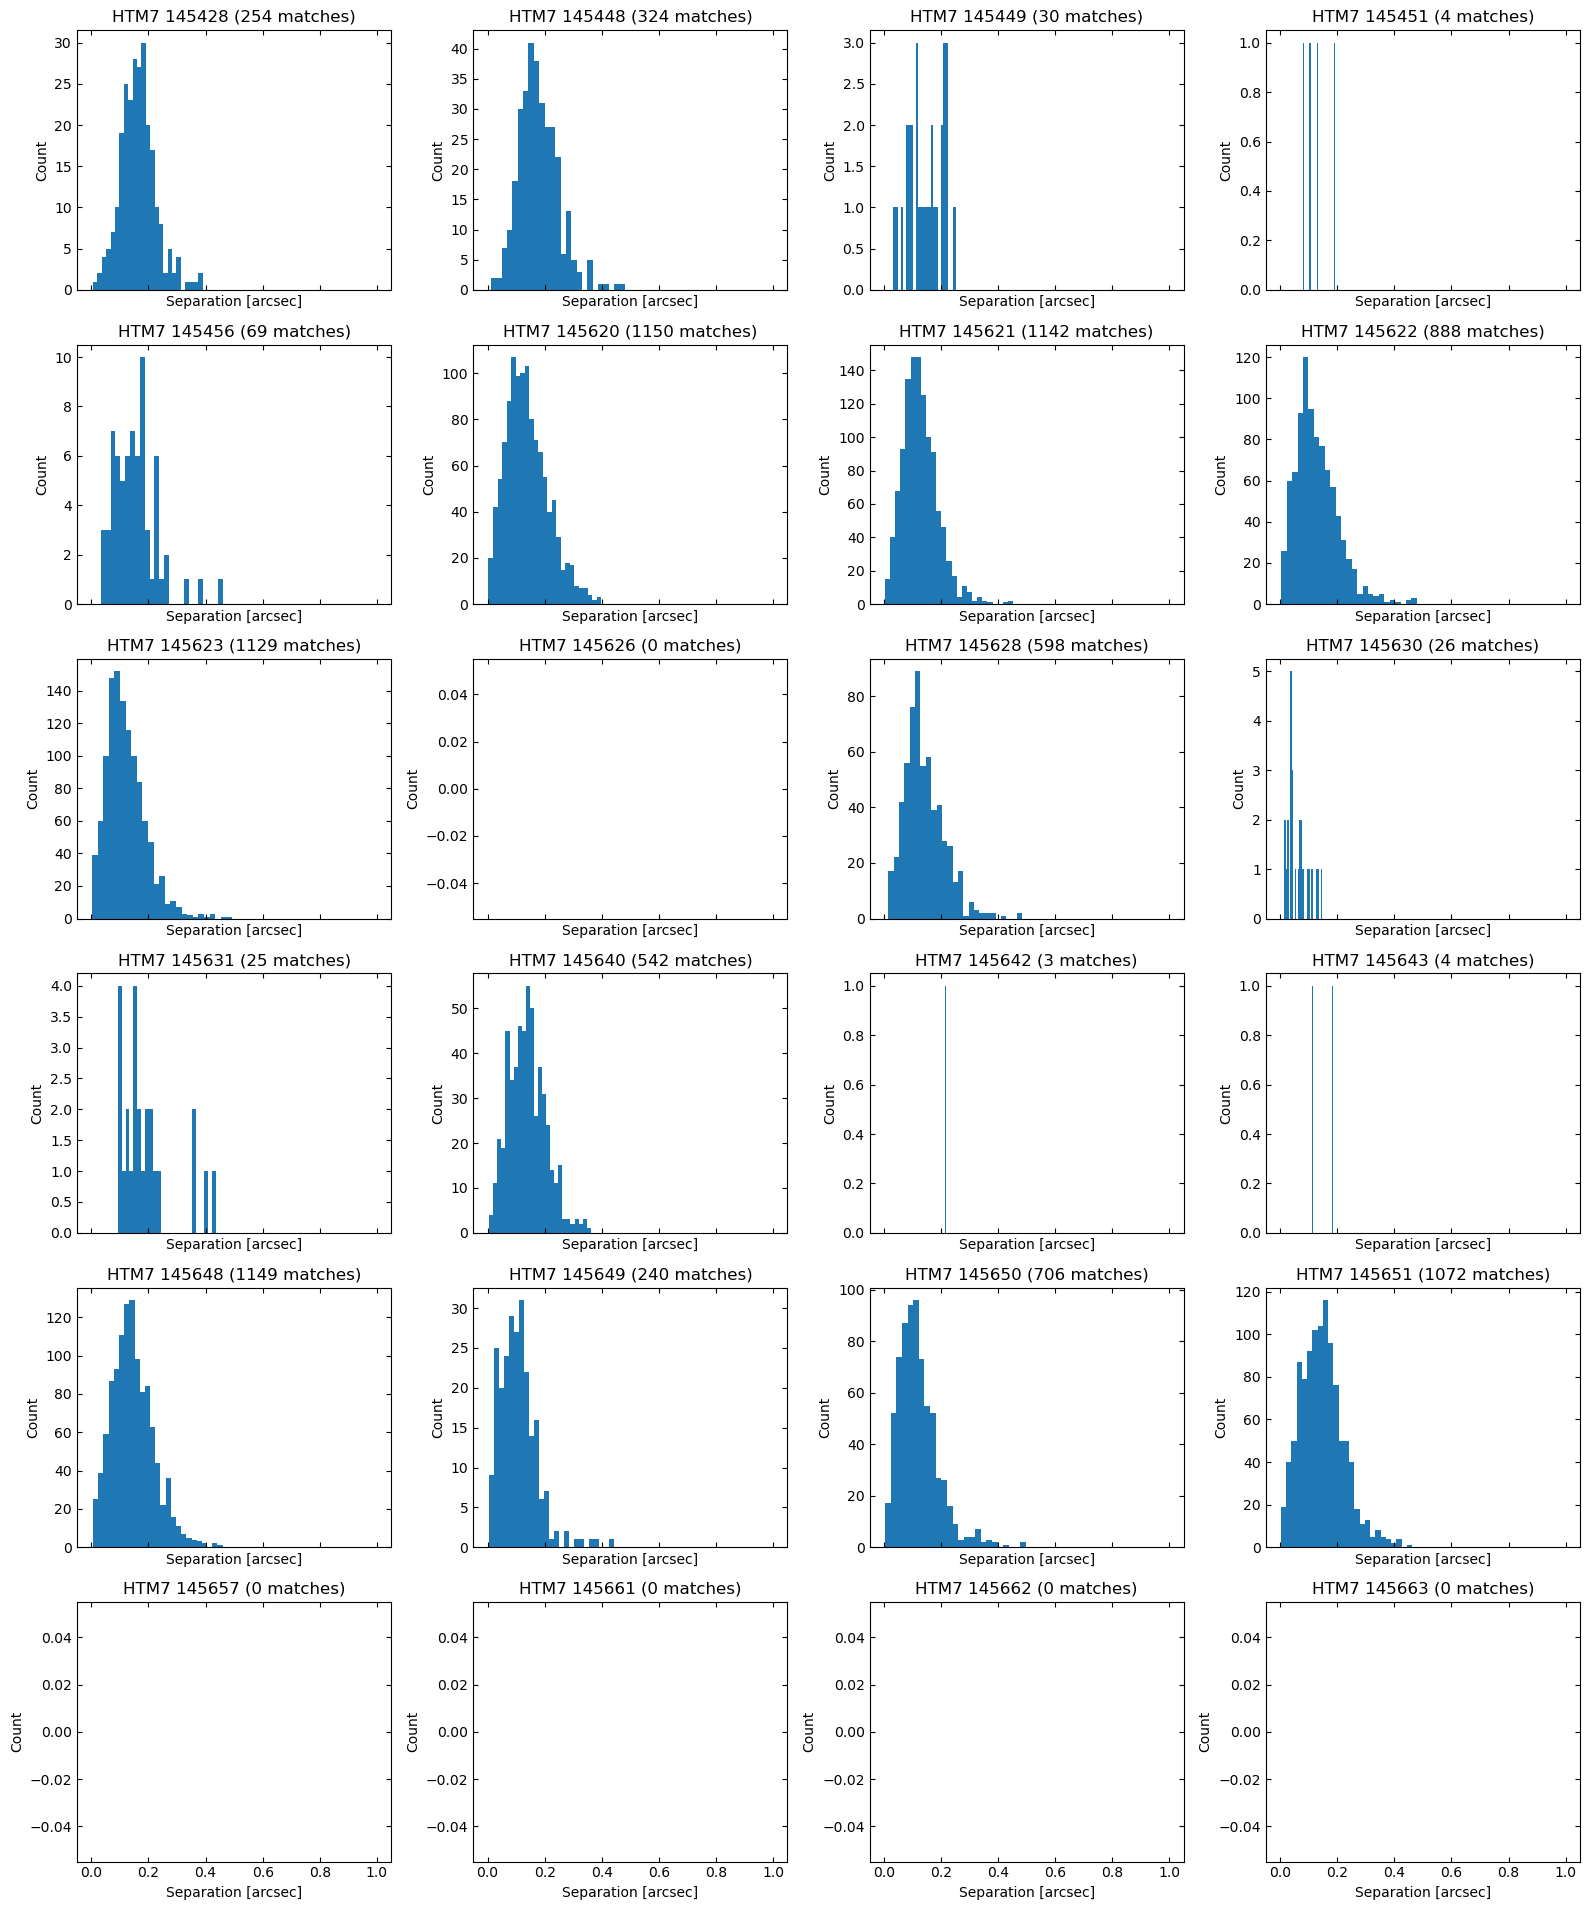

In [20]:
items = sorted(
    all_separations.items(),
    key=lambda item: item[0],
)

n_shards = len(items)
ncols = 4
nrows = int(
    np.ceil(
        n_shards / ncols
    )
)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 3.2 * nrows),
    sharex=True,
    sharey=False,
)

axes = np.atleast_1d(
    axes
).ravel()

for ax, (
    htm_id,
    sep_arcsec,
) in zip(
    axes,
    items,
):

    sep_arcsec = np.asarray(
        sep_arcsec,
        dtype=float,
    )

    sep_arcsec = sep_arcsec[
        np.isfinite(
            sep_arcsec
        )
    ]

    ax.hist(
        sep_arcsec,
        bins=25,
    )

    ax.set_title(
        f"HTM7 {htm_id} "
        f"({len(sep_arcsec)} matches)"
    )
    ax.set_xlabel(
        "Separation [arcsec]"
    )
    ax.set_ylabel(
        "Count"
    )
    ax.tick_params(
        direction="in",
        top=True,
        right=True,
    )

for ax in axes[
    n_shards:
]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Verify the output shards and schema

The checks confirm that every expected HTM7 shard was written, row counts match the Monster inputs, source IDs remain in the same order, all required astrometric and VIRCAM fields are present, and the VIRCAM flux columns carry nJy units.

Output values are inspected with Astropy; no AFW column-view operation is applied to the original Monster catalogues.

In [21]:
output_files = sorted(
    outdir.glob("*.fits")
)

output_ids = sorted(
    int(path.stem)
    for path in output_files
    if path.stem.isdigit()
)

missing_outputs = sorted(
    set(htm7_ids)
    - set(output_ids)
)

extra_outputs = sorted(
    set(output_ids)
    - set(htm7_ids)
)

print(
    f"Input HTM7 shards:  {len(htm7_ids)}"
)
print(
    f"Output HTM7 shards: {len(output_ids)}"
)
print(
    "Missing outputs:",
    missing_outputs,
)
print(
    "Unexpected outputs:",
    extra_outputs,
)

if missing_outputs:
    raise RuntimeError(
        "Some expected HTM7 output shards are missing."
    )

if extra_outputs:
    raise RuntimeError(
        "Unexpected numeric HTM7 output shards are present."
    )

required_output_fields = (
    ASTROMETRY_FIELDS
    + list(
        vista_rename.values()
    )
    + [
        "vista_sep_arcsec",
    ]
)

for shard_id in htm7_ids:

    output_table = Table.read(
        outdir
        / f"{shard_id}.fits"
    )

    input_table = monster_tables[
        shard_id
    ]

    if (
        len(output_table)
        != len(input_table)
    ):
        raise RuntimeError(
            f"Row-count mismatch for HTM7 {shard_id}"
        )

    if not np.array_equal(
        np.asarray(
            output_table["id"],
            dtype=np.int64,
        ),
        np.asarray(
            input_table["id"],
            dtype=np.int64,
        ),
    ):
        raise RuntimeError(
            f"Monster source-ID order changed for HTM7 {shard_id}"
        )

    missing_fields = [
        name
        for name in required_output_fields
        if name not in output_table.colnames
    ]

    if missing_fields:
        raise RuntimeError(
            f"HTM7 {shard_id} is missing fields: "
            + ", ".join(missing_fields)
        )

print(
    "\nAll output shards passed row, ID, and schema checks."
)

test_output = Table.read(
    outdir
    / f"{htm7_ids[0]}.fits"
)

for name in [
    "z2_flux",
    "y2_flux",
    "j_flux",
    "h_flux",
    "ks_flux",
]:
    print(
        f"{name:8s} unit: "
        f"{test_output[name].unit}"
    )

Input HTM7 shards:  24
Output HTM7 shards: 24
Missing outputs: []
Unexpected outputs: []

All output shards passed row, ID, and schema checks.
z2_flux  unit: nJy
y2_flux  unit: nJy
j_flux   unit: nJy
h_flux   unit: nJy
ks_flux  unit: nJy


### Global VIRCAM flux QA

For each band, the notebook reports the number of finite and positive reference fluxes, the median positive flux in nJy, and the corresponding median AB magnitude. These values provide a compact baseline for the later Approach 1 versus Approach 2 comparison.

In [22]:
def njy_to_abmag(flux_njy):
    """Convert positive nJy fluxes to AB magnitudes."""

    flux_njy = np.asarray(
        flux_njy,
        dtype=float,
    )

    mag = np.full(
        len(flux_njy),
        np.nan,
        dtype=float,
    )

    good = (
        np.isfinite(flux_njy)
        & (flux_njy > 0)
    )

    mag[good] = (
        31.4
        - 2.5
        * np.log10(
            flux_njy[good]
        )
    )

    return mag


bands = [
    "z2",
    "y2",
    "j",
    "h",
    "ks",
]

flux_by_band = {
    band: []
    for band in bands
}

for shard_id in htm7_ids:

    tbl = Table.read(
        outdir
        / f"{shard_id}.fits"
    )

    for band in bands:
        flux_by_band[
            band
        ].append(
            np.asarray(
                tbl[
                    f"{band}_flux"
                ],
                dtype=float,
            )
        )

qa_rows = []

for band in bands:

    flux_all = np.concatenate(
        flux_by_band[
            band
        ]
    )

    finite = np.isfinite(
        flux_all
    )

    positive = (
        finite
        & (flux_all > 0)
    )

    if np.any(positive):
        median_flux = float(
            np.median(
                flux_all[
                    positive
                ]
            )
        )
        median_mag = float(
            np.median(
                njy_to_abmag(
                    flux_all[
                        positive
                    ]
                )
            )
        )
    else:
        median_flux = np.nan
        median_mag = np.nan

    qa_rows.append(
        (
            band,
            int(
                np.sum(
                    finite
                )
            ),
            int(
                np.sum(
                    positive
                )
            ),
            median_flux,
            median_mag,
        )
    )

qa_table = Table(
    rows=qa_rows,
    names=[
        "band",
        "n_finite",
        "n_positive",
        "median_flux_nJy",
        "median_AB",
    ],
)

qa_table

band,n_finite,n_positive,median_flux_nJy,median_AB
str2,int64,int64,float64,float64
z2,9355,9168,133464.67766029073,18.586584145543696
y2,9355,9151,160955.30986141533,18.383236728783693
j,9355,9154,189337.33414384178,18.206909399500248
h,9355,9147,203360.40141061906,18.129334023851584
ks,9355,9164,166555.26409499306,18.346104091444285


### Create the Butler HTM7 ingest table

Create filename_to_htm.ecsv, mapping each HTM7 shard filename to its htm7 ID for Butler ingestion.

In [23]:
from pathlib import Path
from astropy.table import Table

# Directory containing the final HTM7 reference-catalogue shards.
refcat_dir = Path("data/video_elais_ap1/the_monster_20250219_vista")

# Build the Butler ingest lookup table.
fits_files = sorted(refcat_dir.glob("[0-9]*.fits"))

if not fits_files:
    raise FileNotFoundError(
        f"No HTM7 FITS files found in {refcat_dir}"
    )

rows = []

for path in fits_files:
    htm7 = int(path.stem)
    rows.append((str(path), htm7))

filename_to_htm = Table(
    rows=rows,
    names=("filename", "htm7"),
)

ecsv_path = refcat_dir.parent / "filename_to_htm.ecsv"

filename_to_htm.write(
    ecsv_path,
    format="ascii.ecsv",
    overwrite=True,
)

print(f"HTM7 shards: {len(filename_to_htm)}")
print(f"Wrote: {ecsv_path}")

filename_to_htm

HTM7 shards: 24
Wrote: data/video_elais_ap1/filename_to_htm.ecsv


filename,htm7
str59,int64
data/video_elais_ap1/the_monster_20250219_vista/145428.fits,145428
data/video_elais_ap1/the_monster_20250219_vista/145448.fits,145448
data/video_elais_ap1/the_monster_20250219_vista/145449.fits,145449
data/video_elais_ap1/the_monster_20250219_vista/145451.fits,145451
data/video_elais_ap1/the_monster_20250219_vista/145456.fits,145456
data/video_elais_ap1/the_monster_20250219_vista/145620.fits,145620
data/video_elais_ap1/the_monster_20250219_vista/145621.fits,145621
data/video_elais_ap1/the_monster_20250219_vista/145622.fits,145622
data/video_elais_ap1/the_monster_20250219_vista/145623.fits,145623


### Summary

The files in `data/video_elais_ap1/the_monster_20250219_vista/` form the **Approach 1** ELAIS-S1 VIRCAM reference catalogue.

The effective VIDEO matching epoch is reproduced from a 0.5-year coarse scan followed by a 0.1-year refinement, with match-count diagnostics retained alongside the separation curves. Monster supplies only the source IDs and astrometric backbone, while VIDEO DR5 supplies ZYJHKs reference photometry in nJy.

Approach 2 can use the same astrometric backbone, epoch determination, Gold matching procedure, and VIDEO JHK measurements, changing only the origin of the VIRCAM Z/Y reference fluxes.